Importing

In [76]:
import pandas as pd # for filing
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visualization
from sklearn.model_selection import train_test_split # for train, test, split
from sklearn.ensemble import AdaBoostClassifier # Boosting model
from sklearn.tree import DecisionTreeClassifier # decison tree model
from sklearn.metrics import classification_report # for accuracy, f1score, precision, recall
from sklearn.ensemble import GradientBoostingClassifier # gradient boosting classifier
from xgboost import XGBClassifier # XG boosting classsifer

Reading dataset

Dataset Link: https://archive.ics.uci.edu/dataset/109/wine?utm_source=chatgpt.com <br>
Column names are
1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash  
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10) Color intensity
11) Hue
12) OD280/OD315 of diluted wines
13) Proline

In [77]:
columns_names = ["class", "alcohol", "malicacid", "ash", "alcalinityofash", "magnesium", "totalphenols", "flavanoids","nonflavanoidphenols", "proanthocyanins", "colorintensity", "hue", "dilutedwines", "proline"]
df = pd.read_csv("/content/wine.data", names =columns_names, sep=",")
df.head()

,class,alcohol,malicacid,ash,alcalinityofash,magnesium,totalphenols,flavanoids,nonflavanoidphenols,proanthocyanins,colorintensity,hue,dilutedwines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Checking for null values

In [78]:
df.isnull().sum()

,0
class,0
alcohol,0
malicacid,0
ash,0
alcalinityofash,0
magnesium,0
totalphenols,0
flavanoids,0
nonflavanoidphenols,0
proanthocyanins,0


Basic exploring data

In [79]:
print("Number of records: ", len(df))
print("Number of wines of type 1: ", len(df[df["class"] == 1]))
print("Number of wines of type 2: ", len(df[df["class"] == 2]))
print("Number of wines of type 3: ", len(df[df["class"] == 3]))

Number of records:  178
Number of wines of type 1:  59
Number of wines of type 2:  71
Number of wines of type 3:  48


/tmp/ipython-input-2606822335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='viridis')


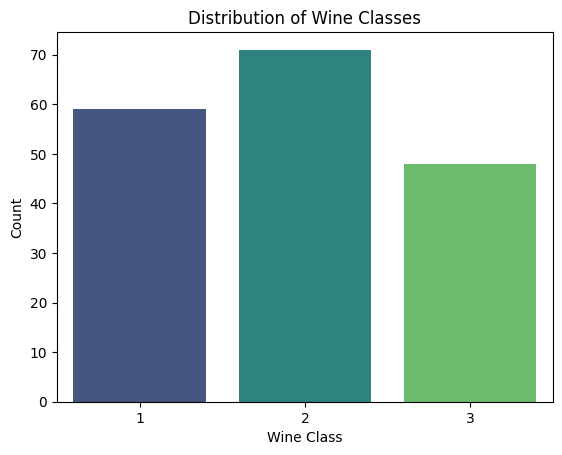

In [80]:
sns.countplot(data=df, x='class', palette='viridis')
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()

alchohol vd flavanoids

Text(0, 0.5, 'Flavanoids')

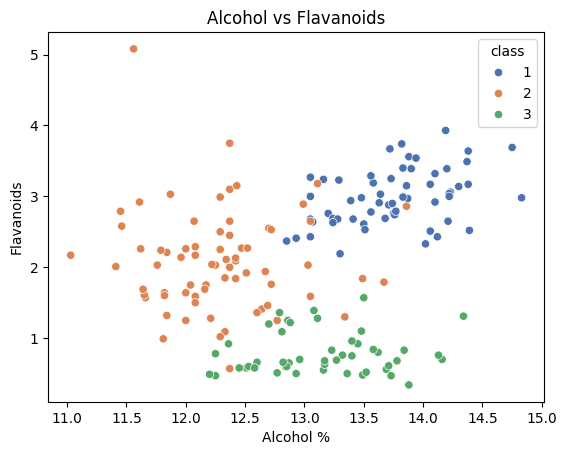

In [93]:
sns.scatterplot(data=df, x='alcohol', y='flavanoids', hue='class', palette='deep')
plt.title('Alcohol vs Flavanoids')
plt.xlabel('Alcohol %')
plt.ylabel('Flavanoids')

Alcohol vs Ash scatter plot

Text(0.5, 1.0, 'Alcohol vs Ash')

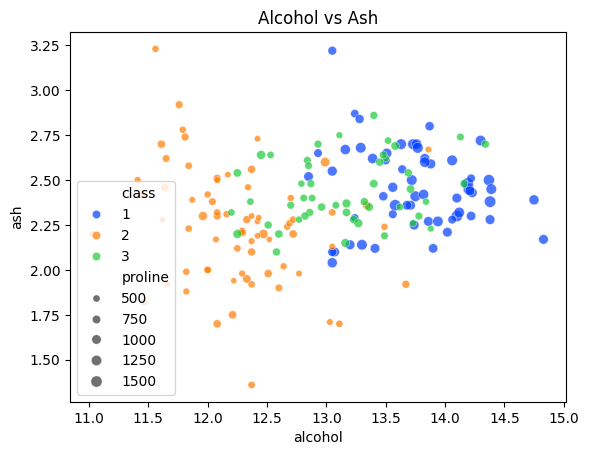

In [99]:
sns.scatterplot(data=df, x='alcohol', y='ash', hue='class', size='proline', palette='bright', alpha=0.7)
plt.title('Alcohol vs Ash')

Alcohol vs proline regression plot

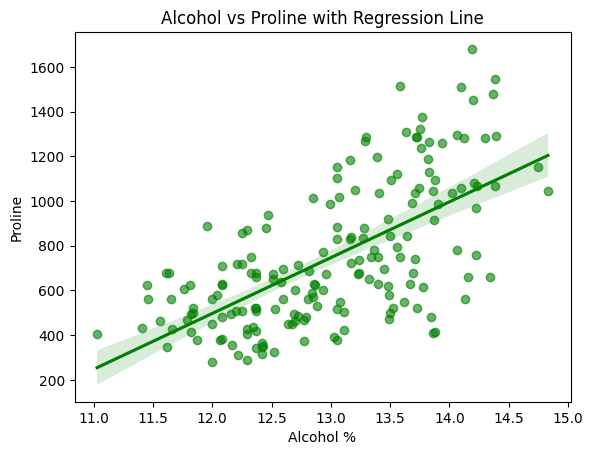

In [94]:
sns.regplot(data=df, x='alcohol', y='proline', color='green', scatter_kws={'alpha':0.6})
plt.title('Alcohol vs Proline with Regression Line')
plt.xlabel('Alcohol %')
plt.ylabel('Proline')
plt.show()

Getting X, Y splits

In [81]:
x = df[df.columns[1:]]
y = df["class"] - 1 # Subtract 1 to make classes 0, 1, and 2

Train Test split

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Model 1: AdaBoostClassifier

In [83]:
ABC = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), # small week learners
    n_estimators=50,   # number of small weak learners
    learning_rate=1.0, # step size
    random_state=42
  )

Training and Testing

In [84]:
model1 = ABC.fit(x_train, y_train)
y_pred = model1.predict(x_test)

Classification Report

In [85]:
print(classification_report(y_test, y_pred))
print("Test score: ", ABC.score(x_test, y_test))
print("Train score: ", ABC.score(x_train, y_train)) # small diff. means no over fitting

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.93      0.93      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Test score:  0.9444444444444444
Train score:  1.0


Model 2: GradientBoostingClassifier

In [86]:
GBC = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

Training and Testing

In [87]:
model2 = GBC.fit(x_train, y_train)
y_pred = model2.predict(x_test)

Model Classification Report

In [88]:
print(classification_report(y_test, y_pred))
print("Test score: ", GBC.score(x_test, y_test))
print("Train score: ", GBC.score(x_train, y_train)) # small diff. means no over fitting

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.93      0.93      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Test score:  0.9444444444444444
Train score:  1.0


Model 3: XGBClassifier

In [89]:
XGB = XGBClassifier(
    n_estimators=2,
    max_depth=2,
    learning_rate=1,
    objective='multi:softprob', # Change objective for multi-class classification
    num_class=3 # Specifying the number of classes
)

Training and Prediction

In [90]:
model3 = XGB.fit(x_train, y_train)
y_pred = model3.predict(x_test)

Model classification report

In [91]:
print(classification_report(y_test, y_pred))
print("Test score: ", XGB.score(x_test, y_test))
print("Train score: ", XGB.score(x_train, y_train)) # small diff. means no over fitting

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.93      0.93      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.92        36
   macro avg       0.93      0.91      0.92        36
weighted avg       0.92      0.92      0.92        36

Test score:  0.9166666666666666
Train score:  0.9788732394366197
